In [958]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import dtale
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_style('darkgrid')

In [959]:
def vif_res(df, vars):
    X = df[vars]
    X_with_const = add_constant(X)   

    vif = pd.DataFrame({
        'variable': X_with_const.columns,
        'VIF': [variance_inflation_factor(X_with_const.values, i) 
                for i in range(X_with_const.shape[1])]
    })

    vif = vif[vif['variable'] != 'const'].sort_values('VIF', ascending=False)
    return vif

In [960]:
df = pd.read_csv("./data/eda_data/gios_daily_agg.csv")
df.head()

,date,PM10,PM25,SO2,CO,NO2,O3
0,2020-01-01,20.48,15.73,19.71,0.32,36.37,64.26
1,2020-01-02,77.82,68.60,15.17,1.17,62.94,34.55
2,2020-01-03,60.62,54.66,14.33,1.24,54.66,40.25
3,2020-01-04,9.73,6.76,4.26,0.29,14.91,67.12
4,2020-01-05,13.55,10.24,5.34,0.34,49.86,71.36


In [961]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index('date')

In [962]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

PM10    112
PM25     43
SO2      55
CO       43
NO2      43
O3       79
dtype: int64

Total: 375


In [963]:
mask = (df['PM10'] < df['PM25']) & df['PM10'].notna() & df['PM25'].notna()
df.loc[mask, 'PM10'] = np.nan

In [964]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

PM10    135
PM25     43
SO2      55
CO       43
NO2      43
O3       79
dtype: int64

Total: 398


In [965]:
POLLUTANTS = ["PM10", "PM25", "SO2", "NO2", "O3"]

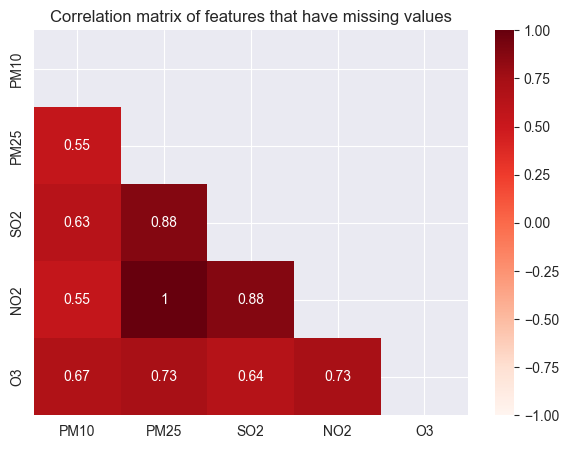

In [966]:
missing_corr = df[POLLUTANTS].isnull().corr()
mask = np.triu(np.ones_like(missing_corr, dtype=bool))

plt.figure(figsize=(7, 5))
sns.heatmap(missing_corr, mask=mask, annot=True, vmin=-1, vmax=1, cmap='Reds', center=0)
plt.title('Correlation matrix of features that have missing values')
plt.savefig(f'./plots/eda_gios/corr_missing.pdf', bbox_inches='tight')
plt.show()

In [967]:
mask_no2 = df["NO2"].isna()
mask_pm25 = df["PM25"].isna()
print(f"NO2 braki:        {mask_no2.sum()}")
print(f"PM25 braki:       {mask_pm25.sum()}")
print(f"Wspólne braki:    {(mask_no2 & mask_pm25).sum()}")
print(f"Tylko NO2:        {(mask_no2 & ~mask_pm25).sum()}")
print(f"Tylko PM25:       {(~mask_no2 & mask_pm25).sum()}")

NO2 braki:        43
PM25 braki:       43
Wspólne braki:    43
Tylko NO2:        0
Tylko PM25:       0


Po zastosowaniu pełnego progu EEA do agregacji dobowej, 43 doby zostały sklasyfikowane jako nieważne dla NO2 i PM2.5 (identyczny zbiór dni, r = 1.0). Wynika to ze strukturalnej cechy wrocławskiej sieci GIOŚ: ciągłe pomiary NO2 i PM2.5 prowadzone są równolegle wyłącznie na stacji Wrocław-Korzeniowskiego, a awarie tej stacji przekładają się bezpośrednio na braki obu zmiennych. Pozostałe stacje (Bartnicza, Orzechowa, NaGrobli) nie mierzą obu zanieczyszczeń jednocześnie, co uniemożliwia uzupełnienie luk poprzez fallback. 

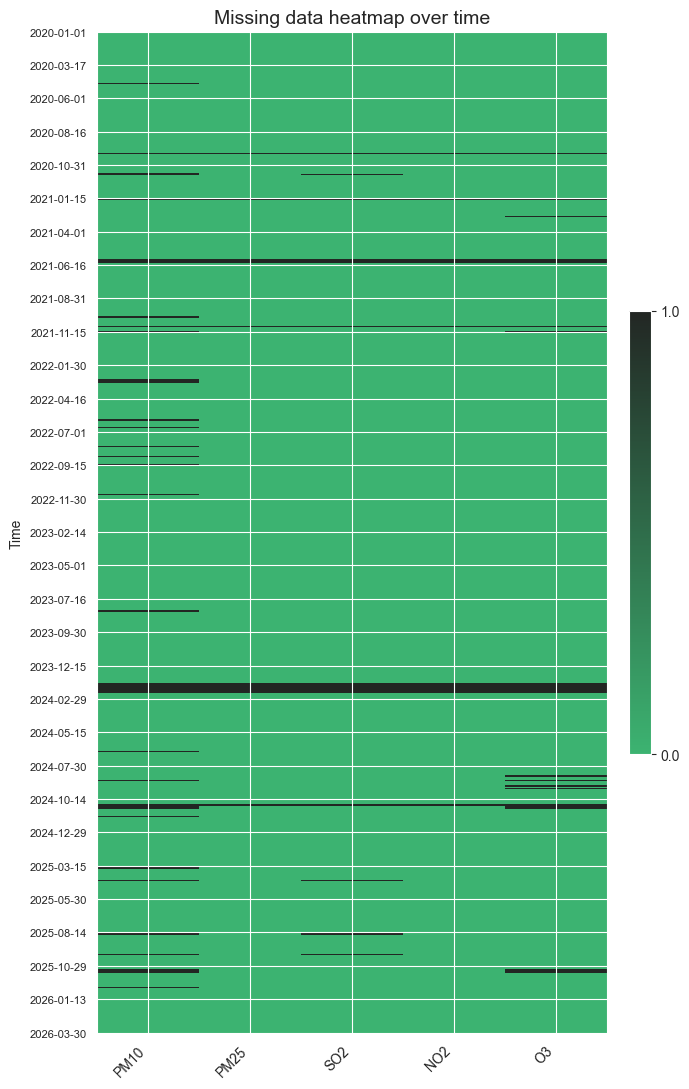

In [968]:
df_plot = df.copy()
if not isinstance(df_plot.index, pd.DatetimeIndex):
    df_plot = df_plot.set_index("date")
df_plot.index = pd.to_datetime(df_plot.index)
df_plot = df_plot.reindex(pd.date_range(df_plot.index.min(), df_plot.index.max(), freq="D"))

# maska braków: 1 = brak, 0 = dane. Czas na osi pionowej, pollutanty na poziomej.
mask = df_plot[POLLUTANTS].isna().astype(int)

fig, ax = plt.subplots(figsize=(7, 11))
my_cmap = sns.color_palette("dark:mediumseagreen_r", as_cmap=True)
im = ax.imshow(mask.values, aspect="auto", cmap=my_cmap, interpolation="nearest")

# oś X: pollutanty
ax.set_xticks(range(len(POLLUTANTS)))
ax.set_xticklabels(POLLUTANTS, rotation=45, ha="right")

# oś Y: daty co ~2 miesiące
n = len(df_plot)
step = max(1, n // 30)  # ok. 30 etykiet na osi
tick_positions = np.arange(0, n, step)
tick_labels = df_plot.index[tick_positions].strftime("%Y-%m-%d")
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=8)

ax.set_ylabel("Time")
ax.set_title("Missing data heatmap over time", fontsize=14)

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0.0", "1.0"])

plt.tight_layout()
plt.savefig(f'./plots/eda_gios/missing_data_heatmap.pdf', bbox_inches='tight')
plt.show()

In [969]:
SHORT_GAP = 3
MEDIUM_GAP = 14

def gap_lengths(series):
    mask = series.isna()
    groups = (mask != mask.shift()).cumsum()
    return mask.groupby(groups).transform('sum').where(mask, 0)


def seasonal_median_lookup(series):
    ref = series.dropna()
    if len(ref) == 0:
        return None
    return ref.groupby(ref.index.dayofyear).median()


def fill_by_lookup(series, mask, lookup):
    out = series.copy()
    if lookup is None or not mask.any():
        return out
    doys = pd.Series(out.index[mask].dayofyear, index=out.index[mask])
    doys = doys.where(doys != 60, 59)  
    out.loc[mask] = doys.map(lookup).values
    return out


def impute_pollutants(df):
    df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq="D")).copy()
    df.index.name = "date"
    
    # 0=oryginał, 1=short, 2=medium, 3=long
    flags = pd.DataFrame(0, index=df.index, columns=POLLUTANTS, dtype=int)
    
    log = {}
    
    for col in POLLUTANTS:
        n_before = df[col].isna().sum()
        lens = gap_lengths(df[col])
        lookup = seasonal_median_lookup(df[col])
        
        # Etap 1: krótkie luki -> interpolacja liniowa
        short_mask = df[col].isna() & (lens <= SHORT_GAP) & (lens > 0)
        df[col] = df[col].interpolate(method="linear", limit=SHORT_GAP, limit_area="inside")
        filled_short = short_mask & df[col].notna()
        flags.loc[filled_short, col] = 1
        n_short = filled_short.sum()
        
        # Etap 2: średnie luki -> mediana sezonowa
        medium_mask = df[col].isna() & (lens > SHORT_GAP) & (lens <= MEDIUM_GAP)
        df[col] = fill_by_lookup(df[col], medium_mask, lookup)
        flags.loc[medium_mask, col] = 2
        n_medium = medium_mask.sum()
        
        # Etap 3: długie luki -> mediana sezonowa (fallback)
        long_mask = df[col].isna()
        df[col] = fill_by_lookup(df[col], long_mask, lookup)
        flags.loc[long_mask, col] = 3
        n_long = long_mask.sum()
        
        log[col] = {
            'NaN_before': int(n_before),
            'imputed_short_≤3d': int(n_short),
            'imputed_medium_4-14d': int(n_medium),
            'imputed_long_>14d': int(n_long),
            'NaN_after': int(df[col].isna().sum()),
        }
    
    return df, flags, log

df_new, flags, log = impute_pollutants(df)

Kaya & Bucak (2025) 

- Krótkie luki (<6 kolejnych godzin) → interpolacja liniowa.
- Dłuższe luki → "data of the previous or next day" 
- Opady → wypełnianie zerem (bo dominują zera).
- Wiatr (kierunek) → kategoria, więc forward/backward fill

In [970]:
pd.DataFrame(log)

,PM10,PM25,SO2,NO2,O3
NaN_before,135,43,55,43,79
imputed_short_≤3d,42,4,12,4,17
imputed_medium_4-14d,38,8,9,8,25
imputed_long_>14d,19,19,19,19,19
NaN_after,0,0,0,0,0


In [971]:
before = df_new.where(flags == 0)
rows = {}
for p in POLLUTANTS:
    b, a = before[p].dropna(), df_new[p]
    rows[p] = {
        "mean_before": b.mean(), "mean_after": a.mean(),
        "med_before": b.median(), "med_after": a.median(),
        "std_before": b.std(), "std_after": a.std(),
        "q95_before": b.quantile(.95), "q95_after": a.quantile(.95),
    }
comparison = pd.DataFrame(rows).T.round(2)
# comparison["std_Δ%"] = ((comparison["std_after"] / comparison["std_before"] - 1) * 100).round(1)

In [972]:
comparison

,mean_before,mean_after,med_before,med_after,std_before,std_after,q95_before,q95_after
PM10,24.06,24.10,19.98,20.01,14.55,14.41,53.67,53.16
PM25,16.79,16.78,12.76,12.78,12.48,12.43,42.06,41.60
SO2,9.96,9.92,7.18,7.20,10.32,10.24,25.83,25.79
NO2,41.82,41.75,38.60,38.55,21.33,21.21,81.30,81.15
O3,71.31,71.07,70.41,70.05,31.16,31.11,124.06,124.09


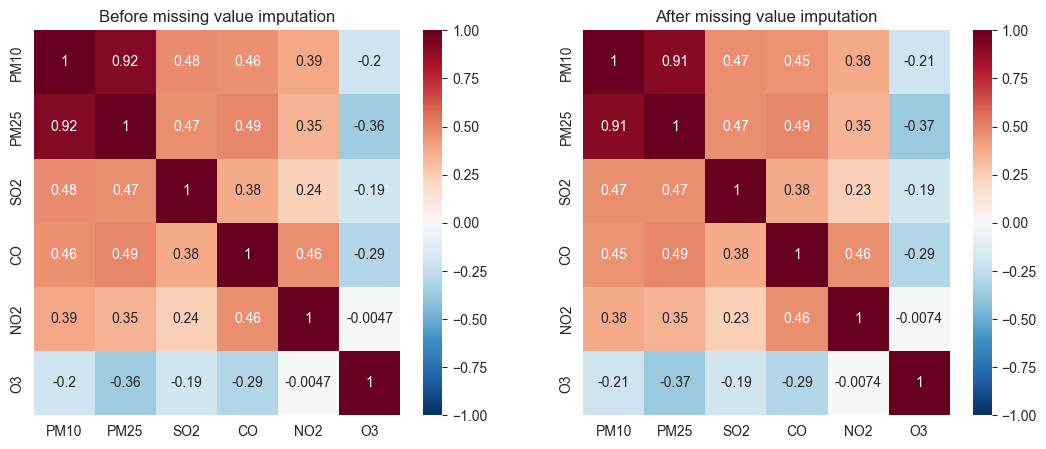

In [973]:
corr_old = df.corr(method='spearman')
corr_new = df_new.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(corr_old, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Before missing value imputation")
sns.heatmap(corr_new, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("After missing value imputation")
plt.savefig(f'./plots/eda_gios/corr_before_after_missing.pdf', bbox_inches='tight')
plt.show()

In [974]:
df_before = df.copy()
df = df_new.copy()

In [975]:
df.describe(include='float64').T

,count,mean,std,min,25%,50%,75%,max
PM10,2283.0,24.099591,14.411594,3.43,14.830,20.01,28.835,155.33
PM25,2283.0,16.780127,12.426021,2.97,8.890,12.78,20.175,142.57
SO2,2283.0,9.922651,10.241200,0.42,5.435,7.20,10.100,121.90
CO,2240.0,1.917763,6.960309,0.21,0.370,0.50,0.800,139.62
NO2,2283.0,41.746907,21.206481,3.19,26.850,38.55,52.770,165.31
O3,2283.0,71.072422,31.114409,2.24,48.185,70.05,93.395,171.30


In [976]:
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
n_cols = len(numeric_cols)

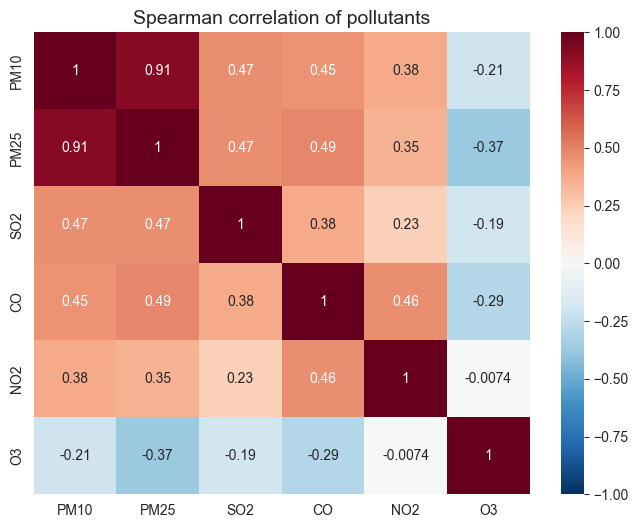

In [977]:
# corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# sns.heatmap(corr_pearson, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0])
# axes[0].set_title("Pearson Correlation")
sns.heatmap(corr_spearman, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes)
axes.set_title("Spearman correlation of pollutants", fontsize=14)
plt.savefig(f'./plots/eda_gios/spearman_gios.pdf', bbox_inches='tight')
plt.show()

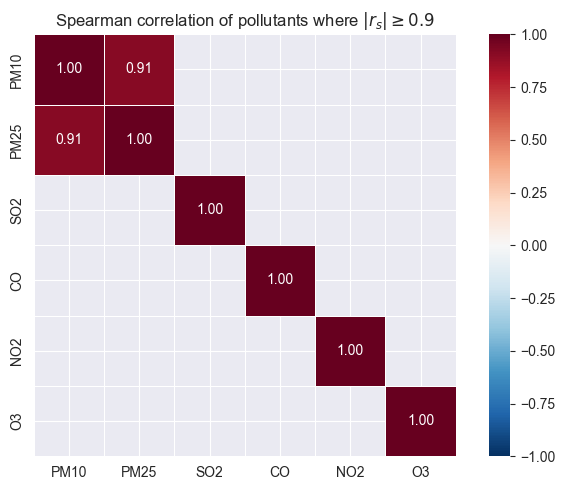

In [978]:
r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# sns.heatmap(r_df_p, annot=True, fmt='.2f',
#             vmin=-1, vmax=1, cmap="RdBu_r", center=0,
#             mask=r_df_p.abs() < 0.9,
#             square=True, linewidths=0.5,
#             ax=axes[0])
# axes[0].set_title('Pearson — r ≥ 0.9')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes)
axes.set_title(rf'Spearman correlation of pollutants where $|r_s| \geq 0.9$', fontsize=12)

plt.tight_layout()
plt.savefig(f'./plots/eda_gios/spearman_mask.pdf', bbox_inches='tight')
plt.show()

PM10 <-> PM2.5: r = 0,92 — ogromna współliniowość. W modelu VAR ta para praktycznie niesie tę samą informację

In [979]:
vif_res(df, POLLUTANTS)



,variable,VIF
2,PM25,8.171998
1,PM10,7.511036
5,O3,1.374398
4,NO2,1.190551
3,SO2,1.074368


In [980]:
# fig, axes = plt.subplots(nrows=n_cols, ncols=2, figsize=(12, 4 * n_cols))

# for i, col in enumerate(numeric_cols):
    
#     sns.boxplot(x=df[col], ax=axes[i][0])
#     axes[i][0].set_title(f'Boxplot: {col}')
    
#     sns.histplot(data=df, x=col, ax=axes[i][1], kde=True, bins=50, stat="density")
#     axes[i][1].set_title(f'Histogram: {col}')

# plt.tight_layout()
# plt.show()

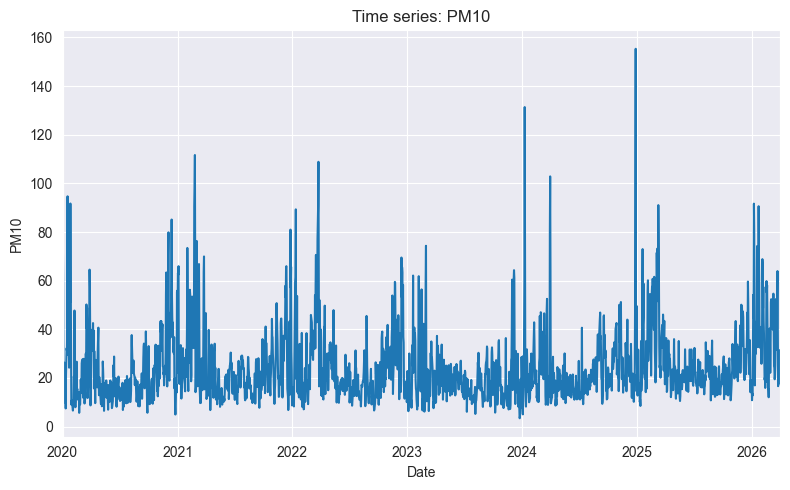

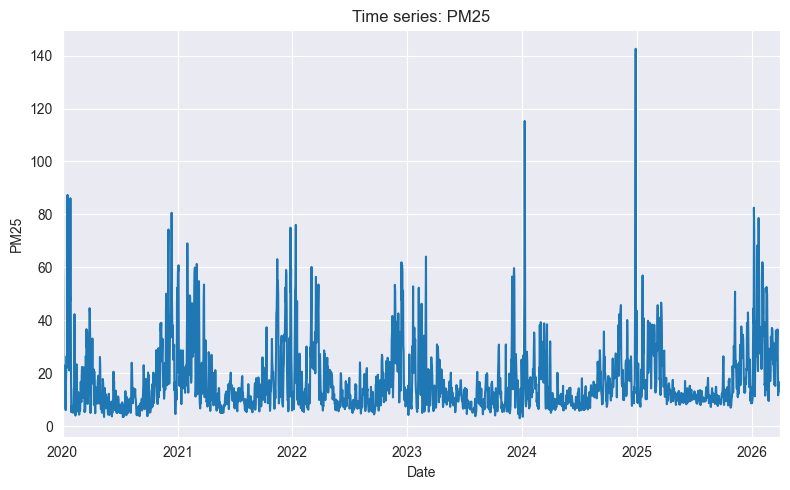

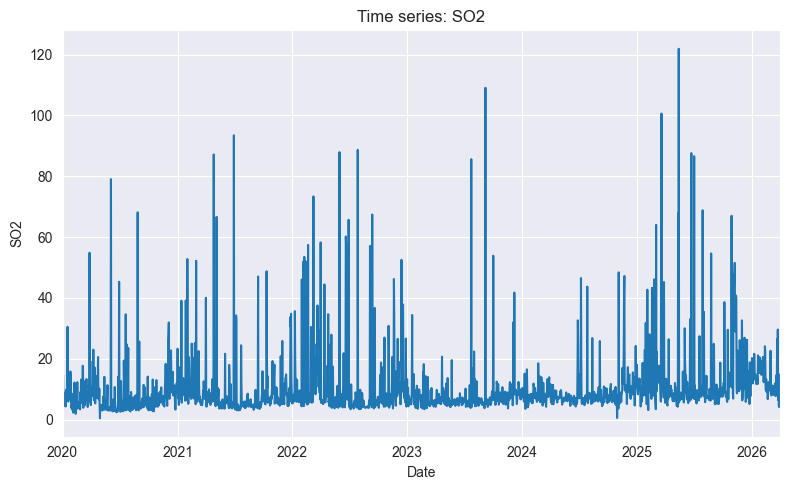

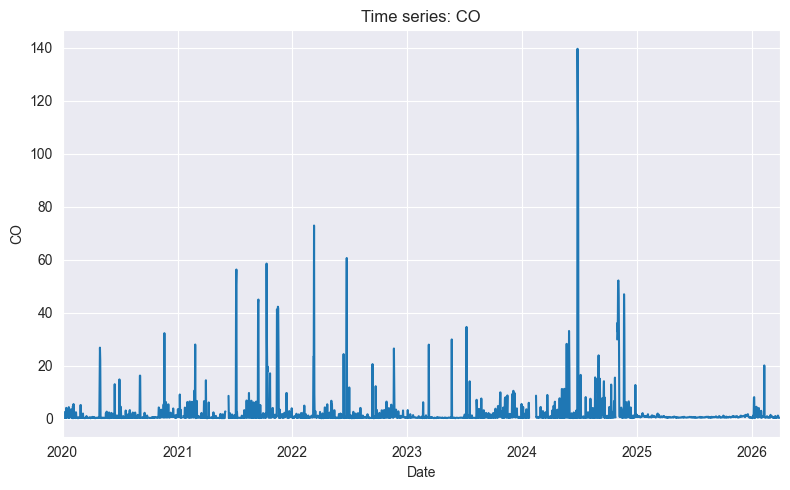

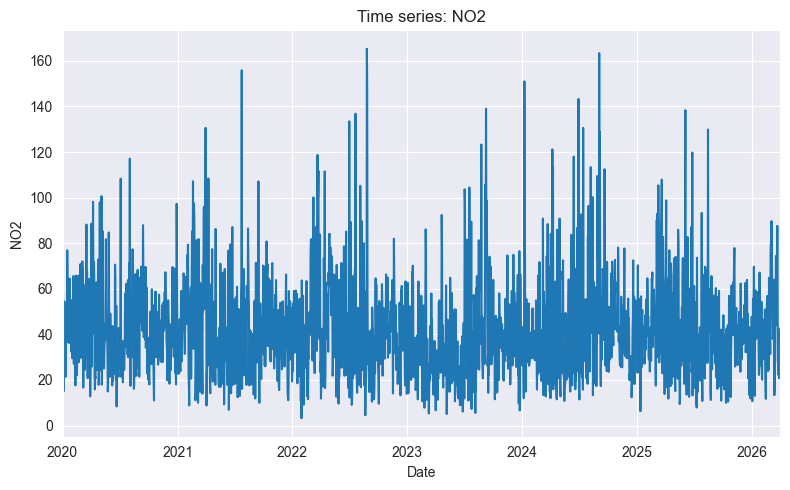

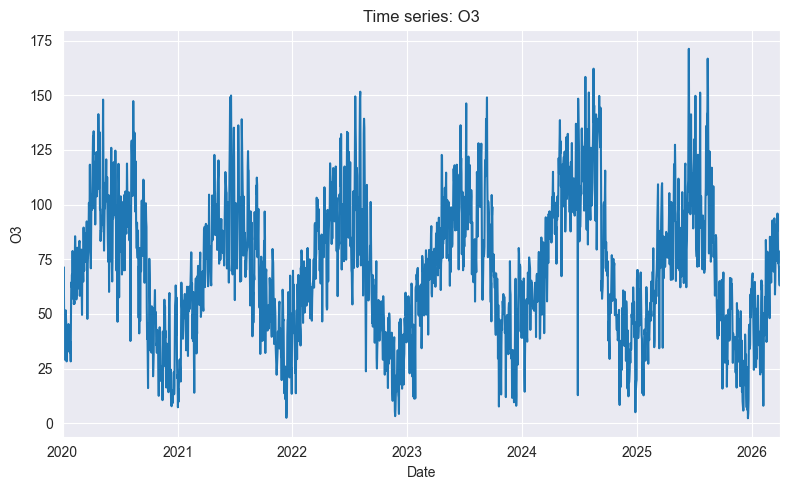

In [981]:
for i, col in enumerate(df.columns):
    df[col].plot(title=f'Time series: {col}', figsize=(8,5))
    plt.ylabel(f'{col}')
    plt.xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'./plots/eda_gios/time_series_{col}.pdf', bbox_inches='tight')
    plt.show()

In [982]:
df['Year'] = df.index.year
df['Month'] = df.index.month_name()
df['DayOfWeek'] = df.index.day_name()
# tydzien , dzizien roboczy i nie
# dummies do tygodniowych

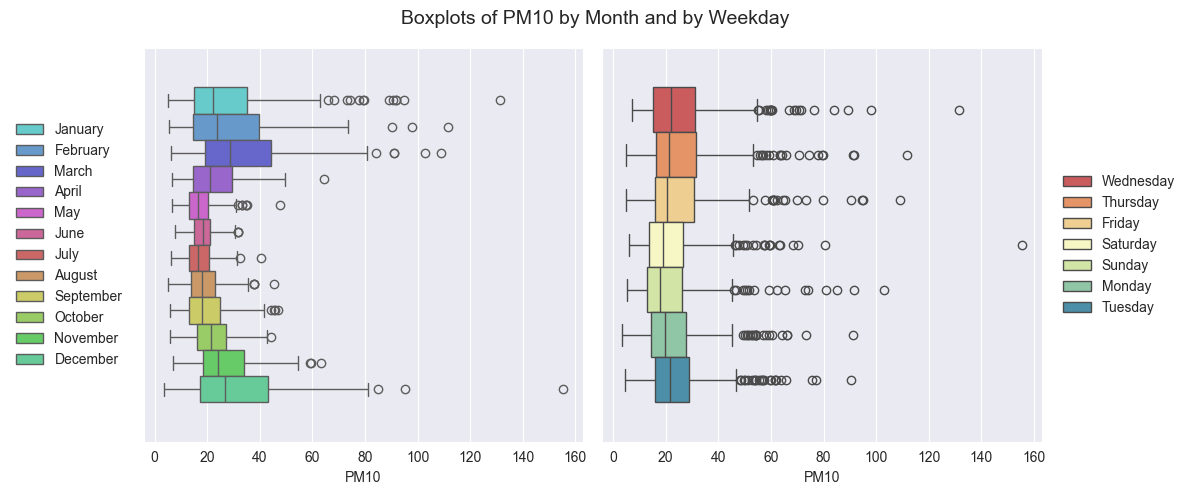

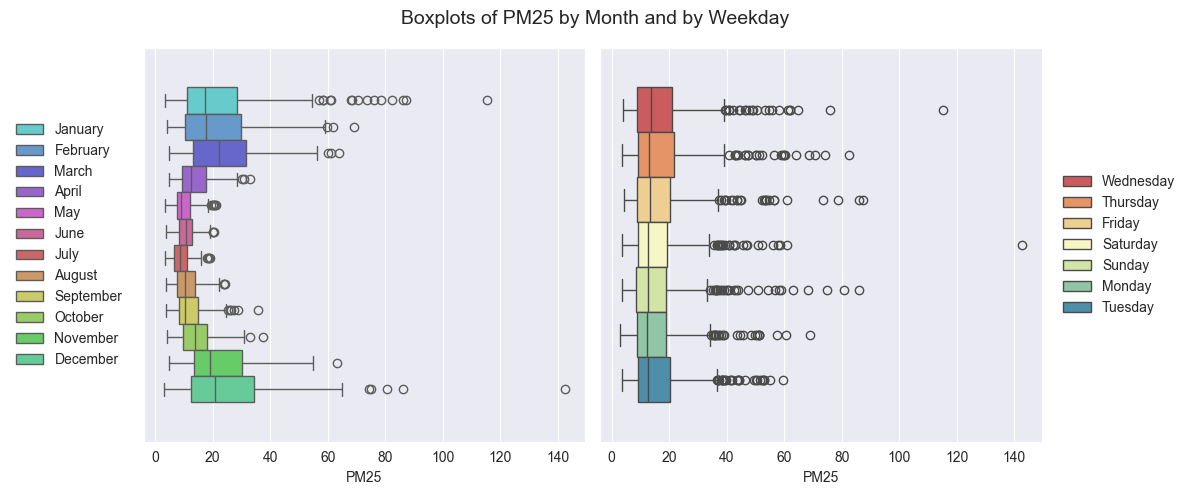

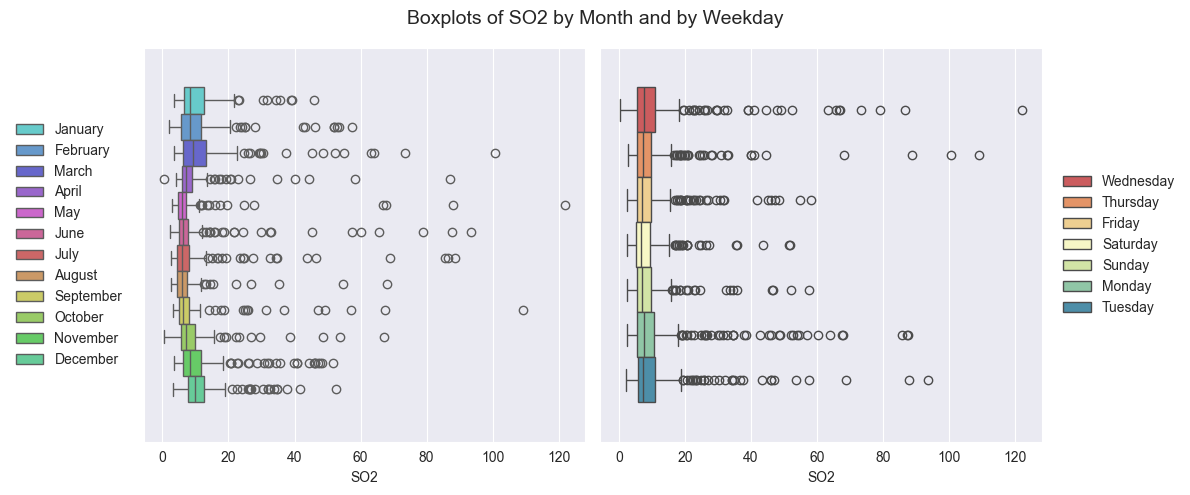

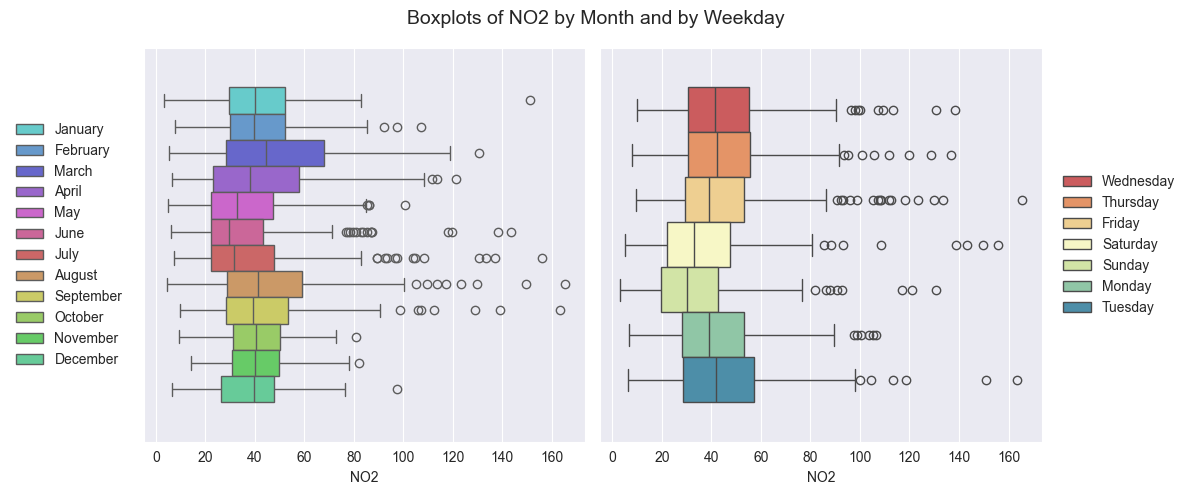

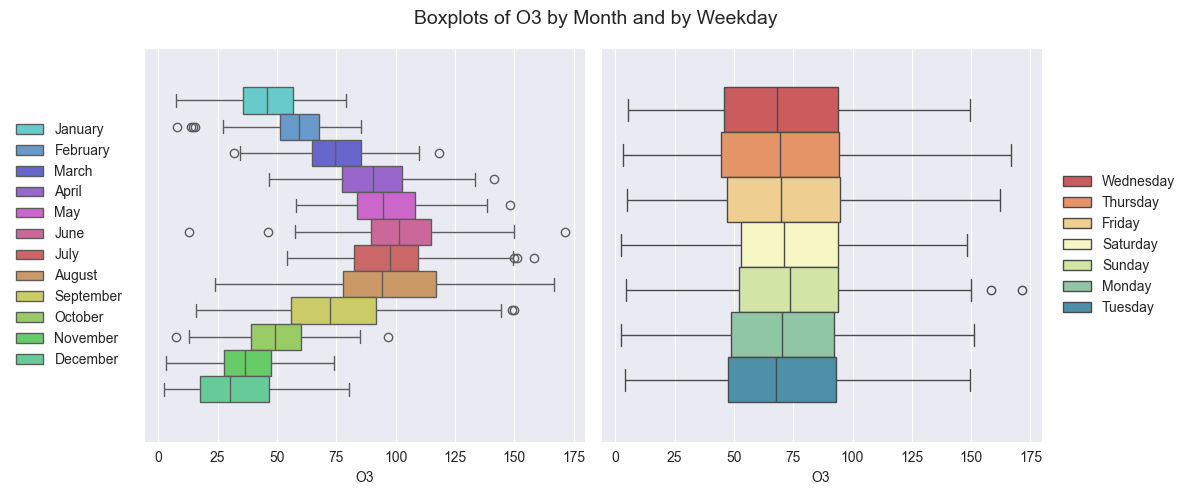

In [983]:
for i, col in enumerate(POLLUTANTS):
    my_col_12 = sns.hls_palette(12, h=0.5)
    my_col_7 = sns.color_palette("Spectral", 7)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.boxplot(data=df, x=col, hue=df['Month'], ax=axes[0], palette=my_col_12)
    sns.boxplot(data=df, x=col, hue=df['DayOfWeek'], ax=axes[1], palette=my_col_7)
    plt.xlabel(f'{col}')
    axes[0].legend(bbox_to_anchor=(-0.02, 0.5), loc='center right', frameon=False)
    axes[1].legend(bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=False)
    plt.suptitle(f'Boxplots of {col} by Month and by Weekday', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'./plots/eda_gios/boxplots_{col}.pdf', bbox_inches='tight')
    plt.show()

In [984]:
heating_months = ['October', 'November', 'December', 'January', 'February','March']
df['Season'] = df['Month'].isin(heating_months).map({True: 'heating', False: 'non-heating'})

working_days = ['Monday', 'Tuesday', 'Wednesday' 'Thursday', 'Friday']
df['Working_day'] = df['DayOfWeek'].isin(working_days).map({True: 'working-day', False: 'weekend'})

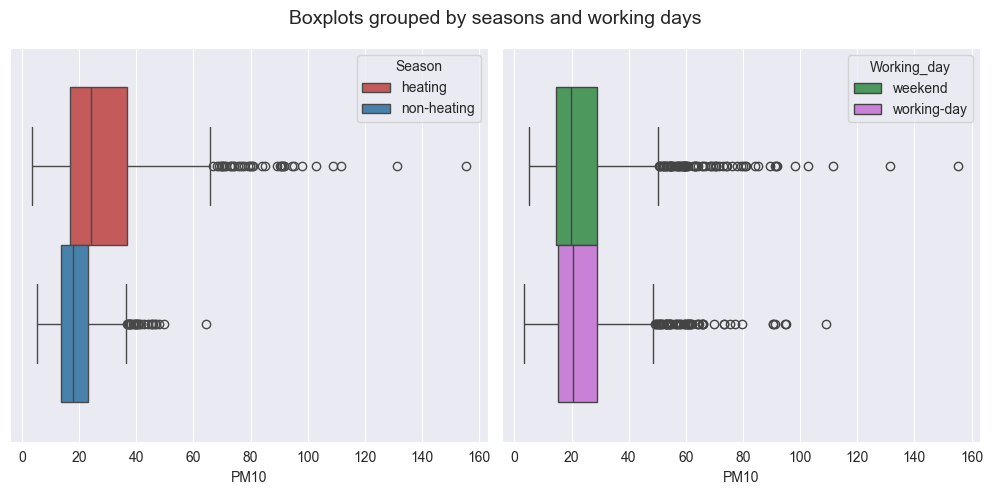

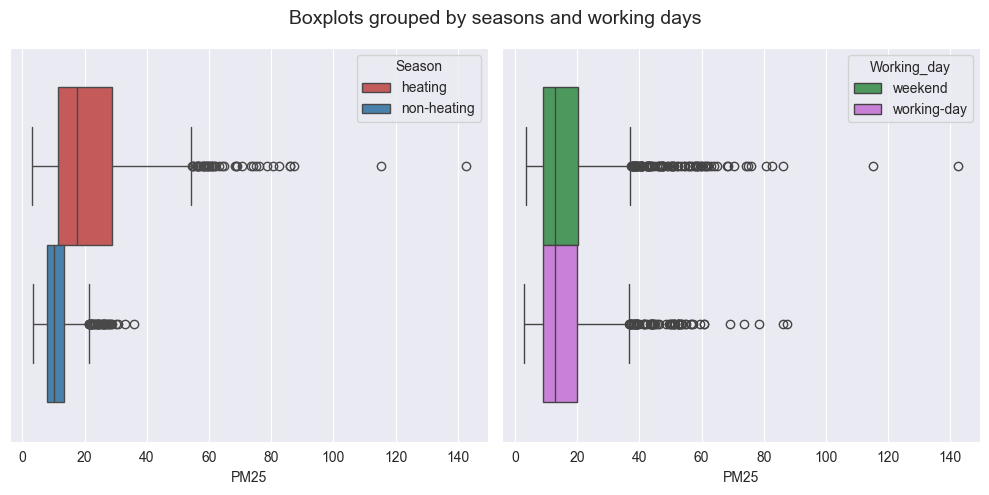

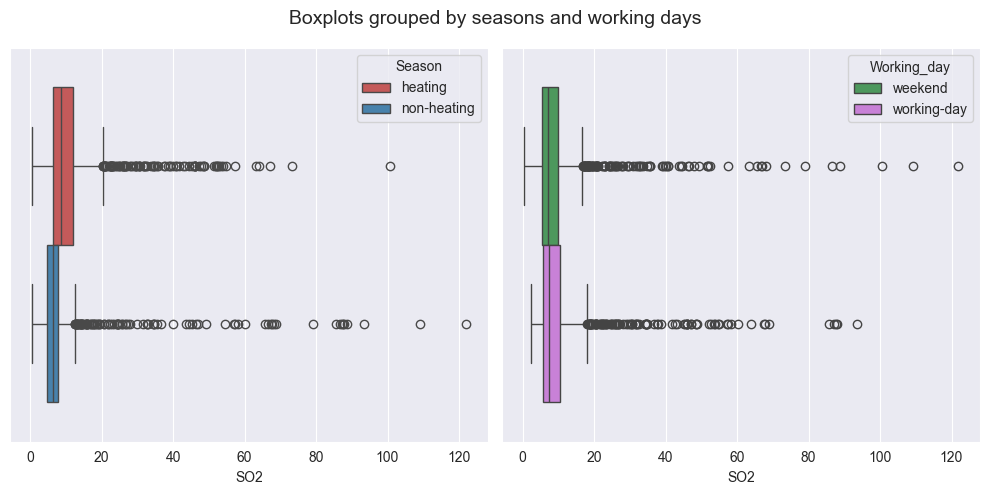

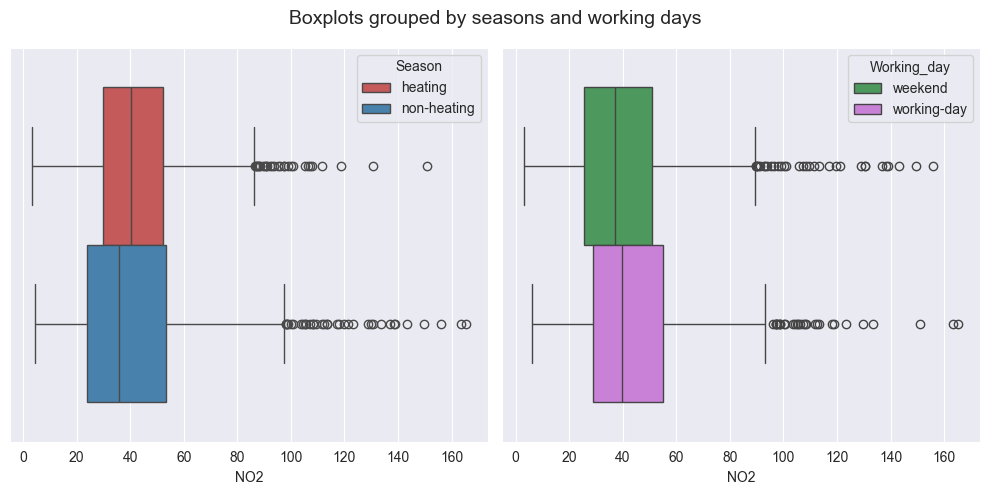

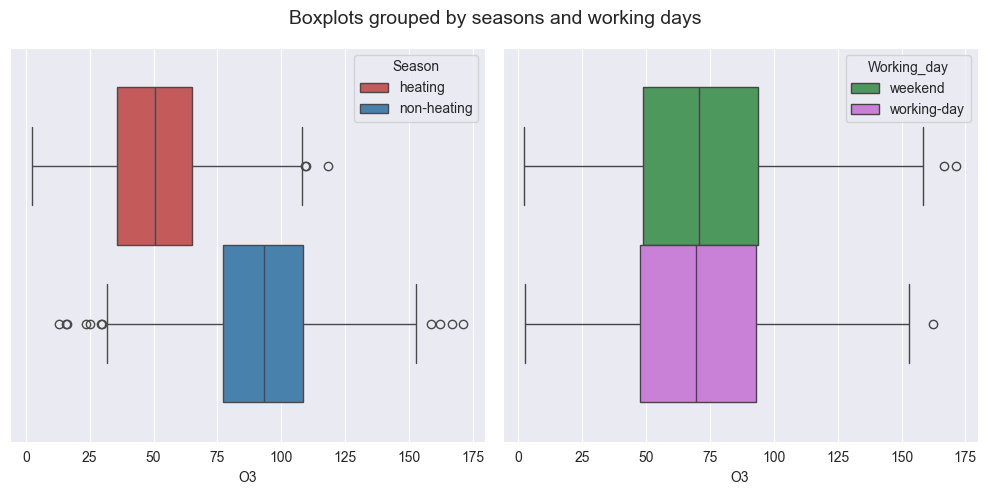

In [985]:
for i, col in enumerate(POLLUTANTS):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    sns.boxplot(data=df, x=col, hue=df['Season'], ax=axes[0], palette = {"heating": "#d54949", "non-heating": "#3785bd"})
    sns.boxplot(data=df, x=col, hue=df['Working_day'], ax=axes[1],  palette={ "working-day": "#D273E5","weekend": "#40A456"})
    plt.xlabel(f'{col}')
    # plt.ylabel('Month')
    plt.suptitle(f'Boxplots grouped by seasons and working days', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'./plots/eda_gios/boxplots_{col}_easier_appendix.pdf', bbox_inches='tight')
    plt.show()

In [986]:
df.groupby('Season')[POLLUTANTS].describe().T

Season          heating  non-heating
PM10 count  1184.000000  1099.000000
     mean     28.788465    19.048066
     std      17.462175     7.339879
     min       3.430000     5.210000
     25%      16.670000    13.710000
     50%      24.250000    17.780000
     75%      36.687500    22.960000
     max     155.330000    64.280000
PM25 count  1184.000000  1099.000000
     mean     22.020053    11.134929
     std      14.841866     4.697592
     min       2.970000     3.410000
     25%      11.457500     7.950000
     50%      17.495000    10.120000
     75%      28.685000    13.305000
     max     142.570000    35.730000
SO2  count  1184.000000  1099.000000
     mean     11.074784     8.681409
     std       9.139426    11.180802
     min       0.510000     0.420000
     25%       6.300000     4.820000
     50%       8.600000     6.280000
     75%      11.900000     7.900000
     max     100.600000   121.900000
NO2  count  1184.000000  1099.000000
     mean     42.285762    41.166375
     std      18.279118    23.958522
     min       3.190000     4.520000
     25%      29.863750    23.725000
     50%      40.370000    35.620000
     75%      52.400000    53.360000
     max     151.000000   165.310000
O3   count  1184.000000  1099.000000
     mean     50.256077    93.498766
     std      20.883216    23.906296
     min       2.240000    12.800000
     25%      35.790000    77.320000
     50%      50.510000    93.320000
     75%      64.865000   108.345000
     max     118.280000   171.300000

In [987]:
df.groupby('Working_day')[POLLUTANTS].describe().T

Working_day      weekend  working-day
PM10 count   1305.000000   978.000000
     mean      23.942902    24.308670
     std       14.903078    13.733177
     min        5.030000     3.430000
     25%       14.560000    15.157500
     50%       19.780000    20.495000
     75%       28.860000    28.747500
     max      155.330000   108.870000
PM25 count   1305.000000   978.000000
     mean      16.961933    16.537532
     std       12.916839    11.741338
     min        3.410000     2.970000
     25%        8.910000     8.867500
     50%       12.820000    12.720000
     75%       20.230000    19.982500
     max      142.570000    87.350000
SO2  count   1305.000000   978.000000
     mean       9.487740    10.502977
     std        9.762411    10.825102
     min        0.420000     2.280000
     25%        5.290000     5.580000
     50%        7.100000     7.345000
     75%        9.830000    10.562500
     max      121.900000    93.460000
NO2  count   1305.000000   978.000000
     mean      40.137764    43.894076
     std       20.806216    21.553330
     min        3.190000     6.120000
     25%       25.390000    28.705000
     50%       37.200000    39.765000
     75%       51.030000    55.140000
     max      155.900000   165.310000
O3   count   1305.000000   978.000000
     mean      71.758696    70.156688
     std       31.166623    31.036888
     min        2.240000     2.440000
     25%       48.630000    47.590000
     50%       70.690000    69.515000
     75%       93.820000    92.985000
     max      171.300000   162.210000

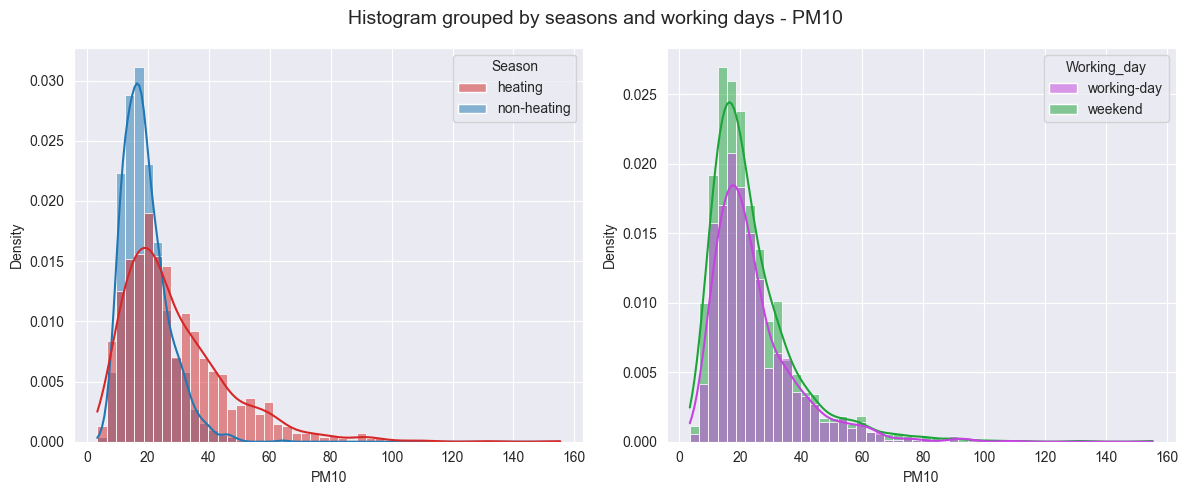

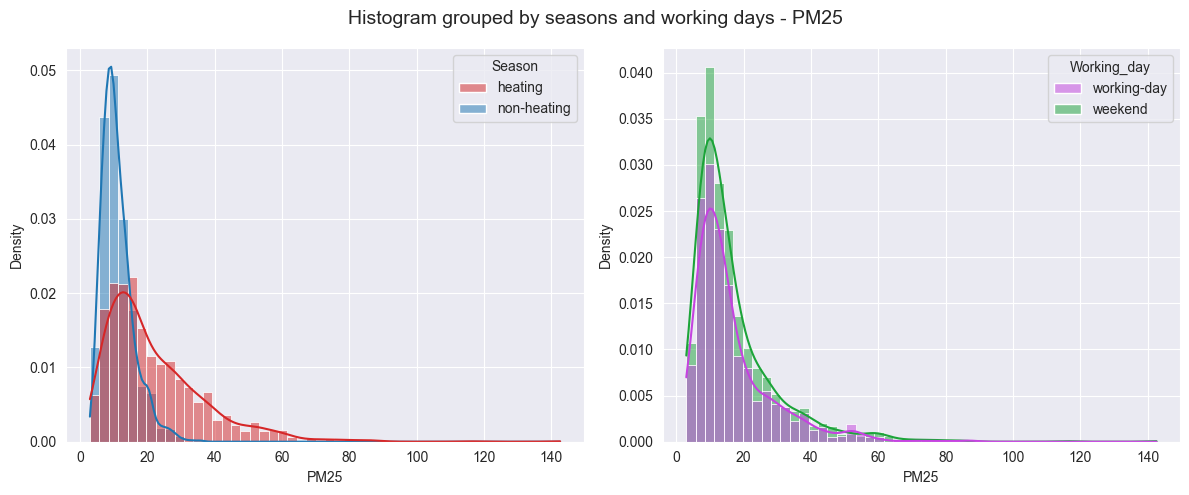

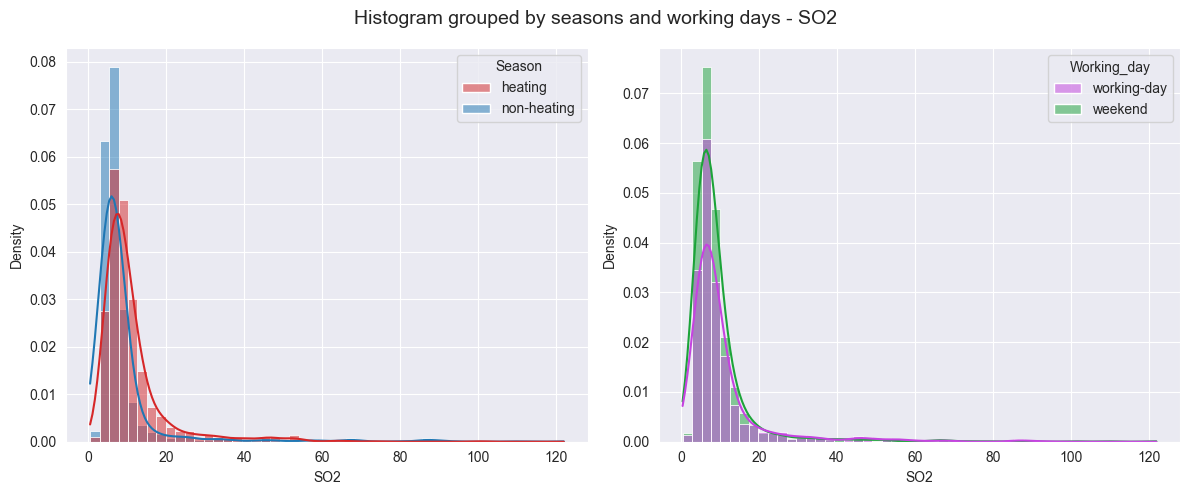

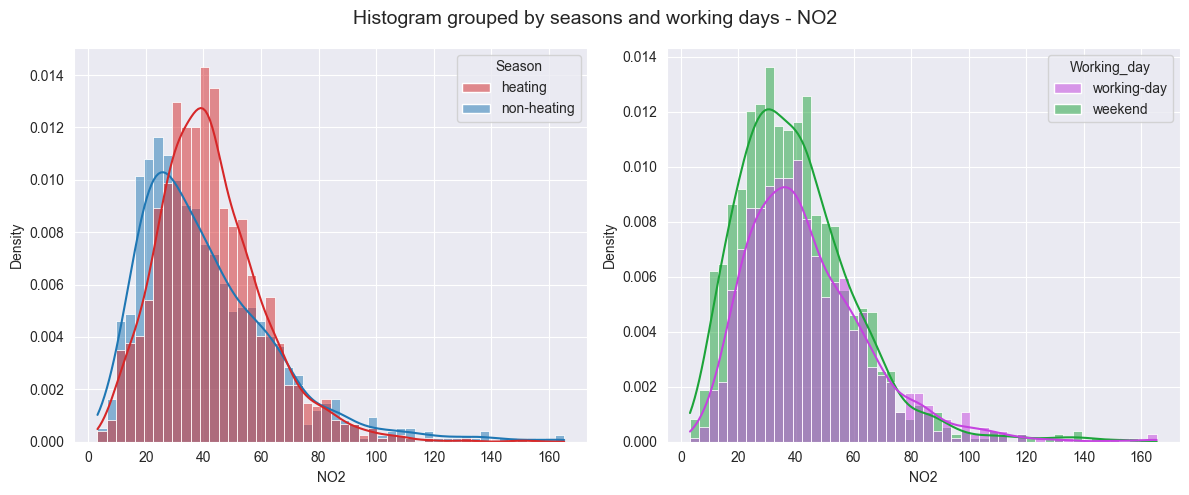

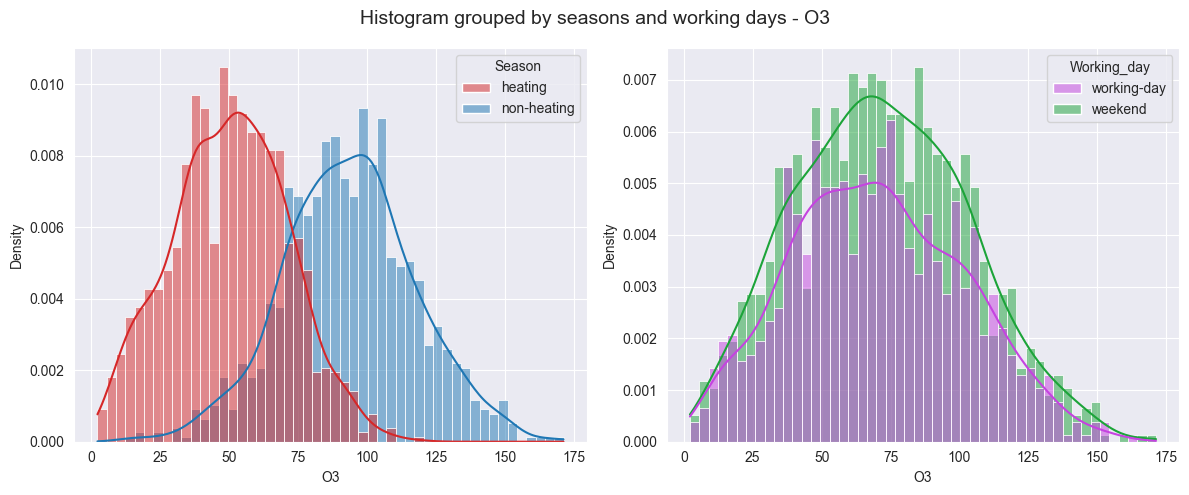

In [988]:
for i, col in enumerate(POLLUTANTS): # 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.histplot(data=df, x=col, ax=axes[0], kde=True, bins=50, stat="density", hue=df['Season'], palette = {"heating": "#d62728", "non-heating": "#1f77b4"})
    # axes[0].set_title(f'Histogram: {col}')
    
    sns.histplot(data=df, x=col, ax=axes[1], kde=True, bins=50, stat="density", hue=df['Working_day'], palette={ "working-day": "#C543E0","weekend": "#1CA439"}, hue_order=["working-day", "weekend"])
    # axes[1].set_title(f'Histogram: {col}')
    plt.suptitle(f'Histogram grouped by seasons and working days - {col}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'./plots/eda_gios/histograms_{col}.pdf', bbox_inches='tight')
    plt.show()

In [989]:
df_heating = df[df['Season'] == 'heating']
df_non_heating = df[df['Season'] == 'non-heating']

df_weekend = df[df['Working_day'] == 'weekend']
df_weekday = df[df['Working_day'] == 'working-day']

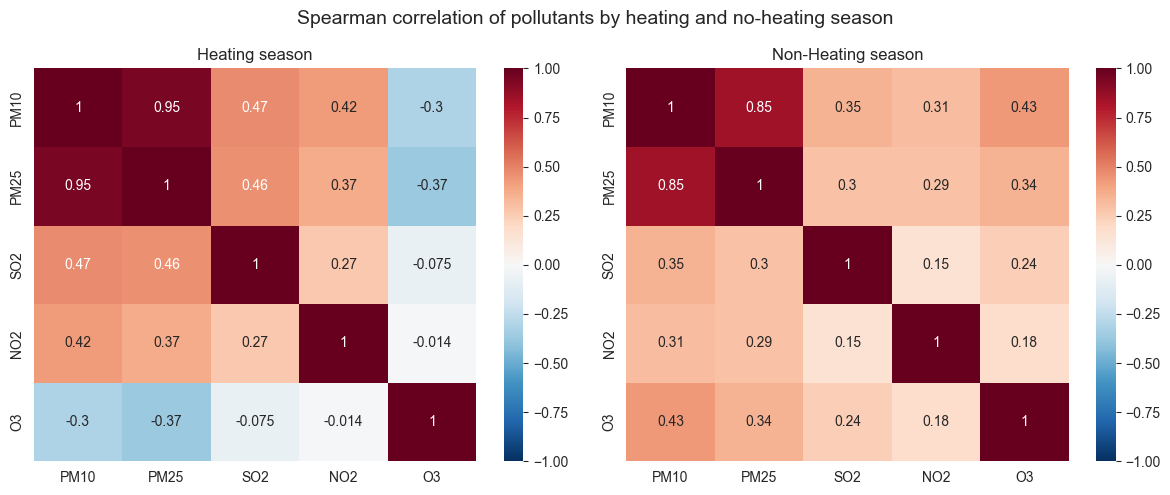

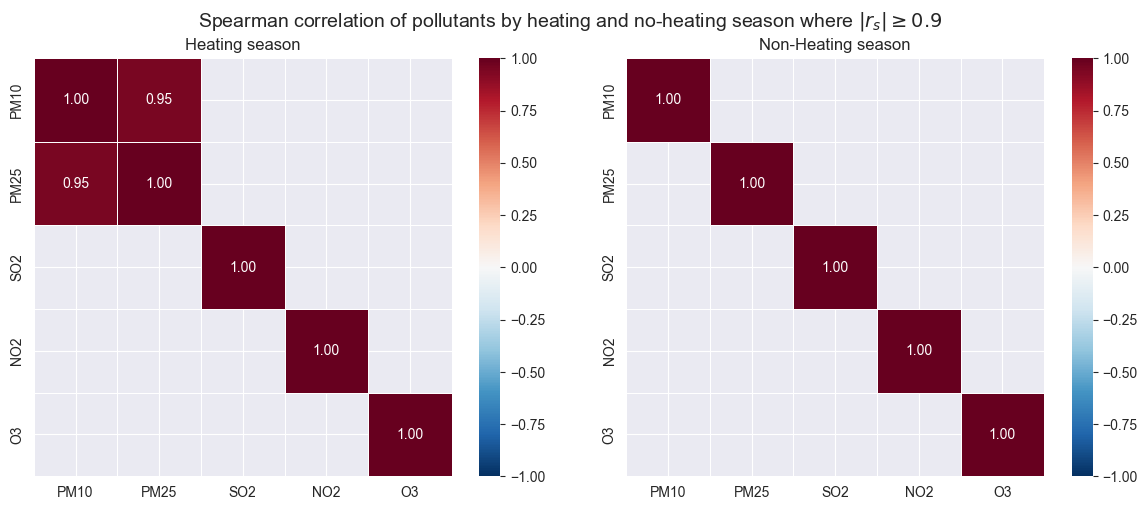

In [990]:
corr_heating = df_heating[POLLUTANTS].corr(method='spearman')
corr_non_heating = df_non_heating[POLLUTANTS].corr(method='spearman')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.heatmap(corr_heating, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title('Heating season')

sns.heatmap(corr_non_heating, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title('Non-Heating season')

plt.suptitle(rf'Spearman correlation of pollutants by heating and no-heating season', fontsize=14)
plt.tight_layout()
plt.savefig(f'./plots/eda_gios/corr_heating_non_heating_{col}.pdf', bbox_inches='tight')
plt.show()


r_df_h = df_heating[POLLUTANTS].corr(method='spearman')
r_df_nh = df_non_heating[POLLUTANTS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(r_df_h, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_h.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Heating season')

sns.heatmap(r_df_nh, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_nh.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Non-Heating season')

plt.suptitle(rf'Spearman correlation of pollutants by heating and no-heating season where $|r_s| \geq 0.9$', fontsize=14)
plt.tight_layout()
plt.savefig(f'./plots/eda_gios/corr_heating_non_heating_mask.pdf', bbox_inches='tight')
plt.show()

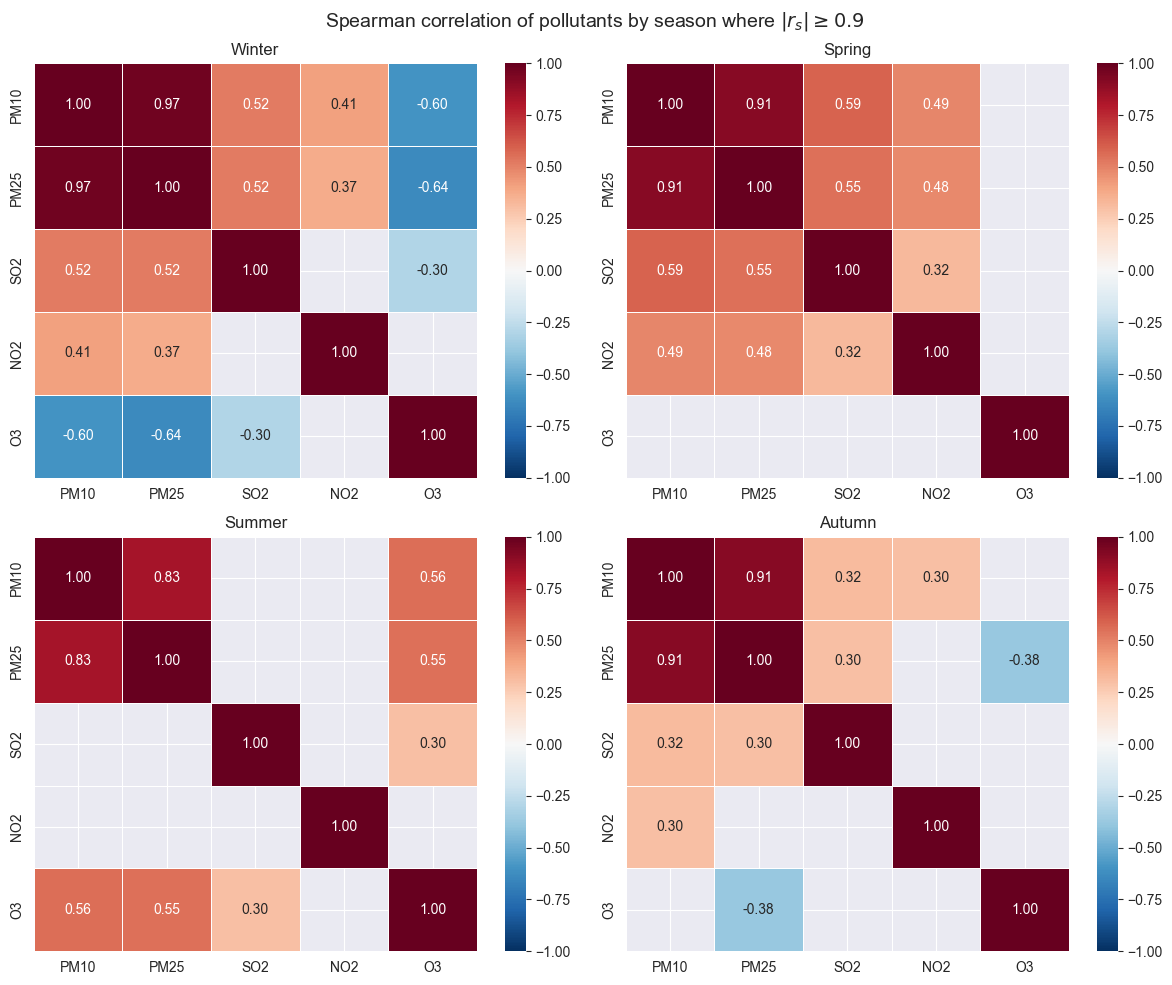

In [991]:
season_mapping = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn',
    11: 'Autumn', 12: 'Winter'
}

df['season_2'] = df.index.month.map(season_mapping)

r_df_w = df[df['season_2'] == 'Winter'][POLLUTANTS].corr(method='spearman')
r_df_s = df[df['season_2'] == 'Spring'][POLLUTANTS].corr(method='spearman')
r_df_su = df[df['season_2'] == 'Summer'][POLLUTANTS].corr(method='spearman')
r_df_a = df[df['season_2'] == 'Autumn'][POLLUTANTS].corr(method='spearman')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(r_df_w, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_w.abs() <= 0.3,
            square=False, linewidths=0.5,
            ax=axes[0, 0])
axes[0, 0].set_title('Winter')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() <= 0.3,
            square=False, linewidths=0.5,
            ax=axes[0, 1])
axes[0, 1].set_title('Spring') 

sns.heatmap(r_df_su, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_su.abs() <= 0.3,
            square=False, linewidths=0.5,
            ax=axes[1, 0])
axes[1, 0].set_title('Summer')

sns.heatmap(r_df_a, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_a.abs() <= 0.3,
            square=False, linewidths=0.5,
            ax=axes[1, 1])
axes[1, 1].set_title('Autumn') 

plt.suptitle(rf'Spearman correlation of pollutants by season where $|r_s| \geq 0.9$', fontsize=14)
plt.tight_layout()
plt.savefig('./plots/eda_gios/spearman_seasons.pdf', bbox_inches='tight')
plt.show()

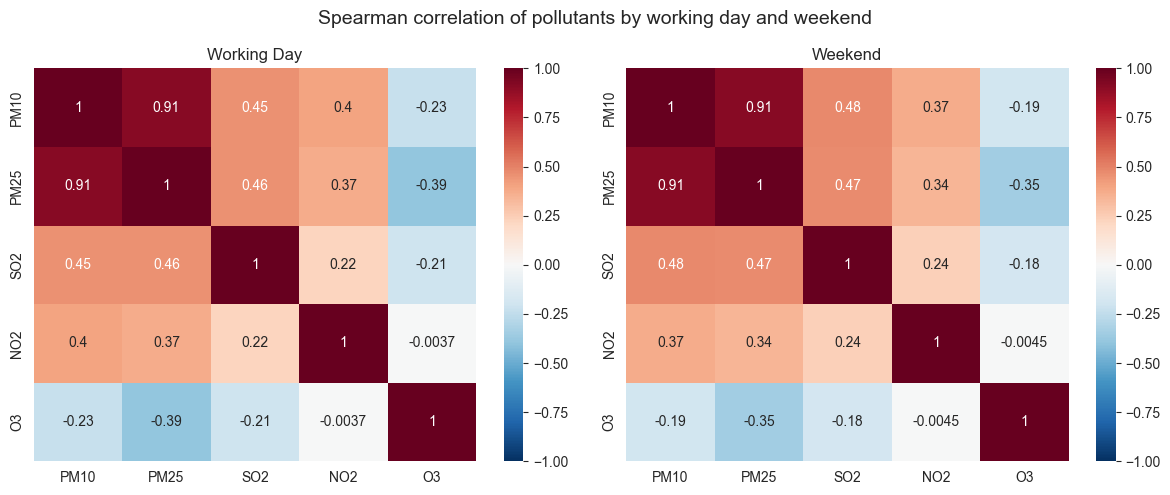

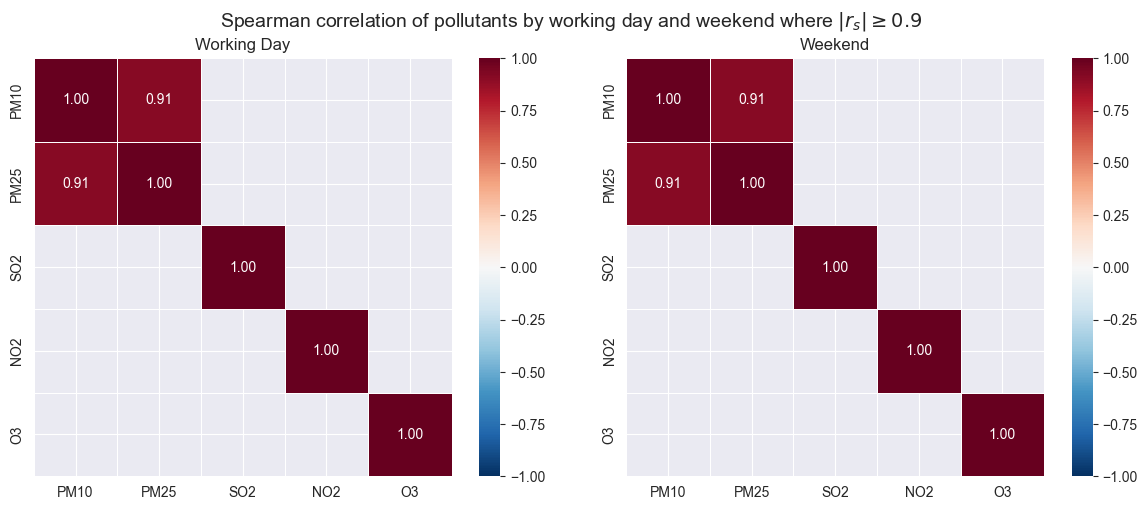

In [992]:
corr_working_day = df_weekday[POLLUTANTS].corr(method='spearman')
corr_weekend = df_weekend[POLLUTANTS].corr(method='spearman')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.heatmap(corr_working_day, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title('Working Day')

sns.heatmap(corr_weekend, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title('Weekend')

plt.suptitle(rf'Spearman correlation of pollutants by working day and weekend', fontsize=14)
plt.tight_layout()
plt.savefig('./plots/eda_gios/spearman_working_weekend.pdf', bbox_inches='tight')
plt.show()

r_df_work = df_weekday[POLLUTANTS].corr(method='spearman')
r_df_weekend = df_weekend[POLLUTANTS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(r_df_work, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_work.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Working Day')

sns.heatmap(r_df_weekend, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_weekend.abs() < 0.9,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Weekend')

plt.suptitle(rf'Spearman correlation of pollutants by working day and weekend where $|r_s| \geq 0.9$', fontsize=14)
plt.tight_layout()
plt.savefig('./plots/eda_gios/spearman_working_weekend_mask.pdf', bbox_inches='tight')
plt.show()

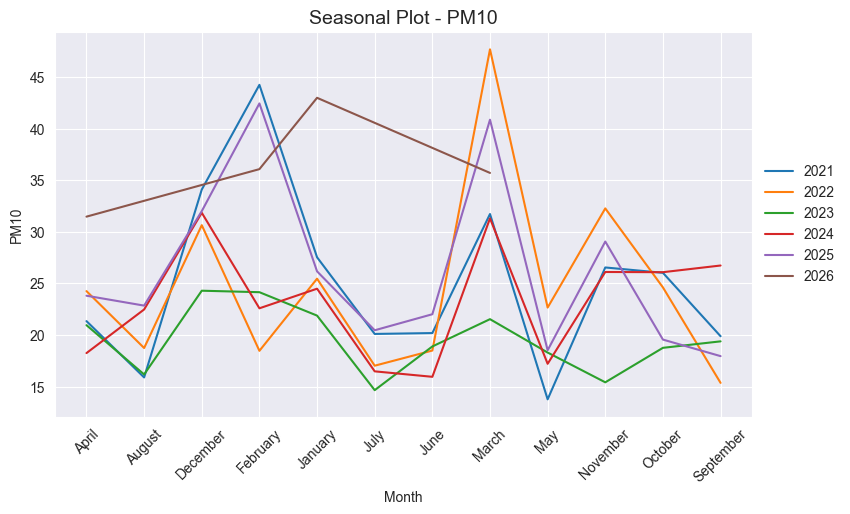

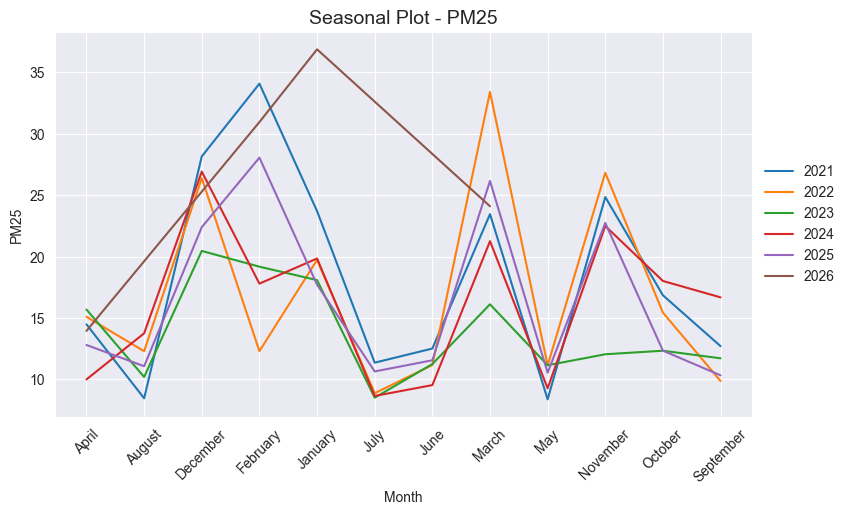

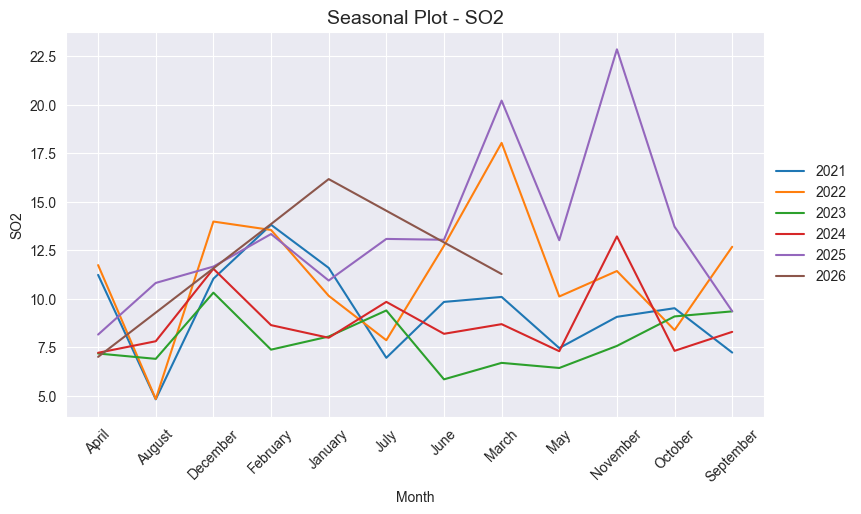

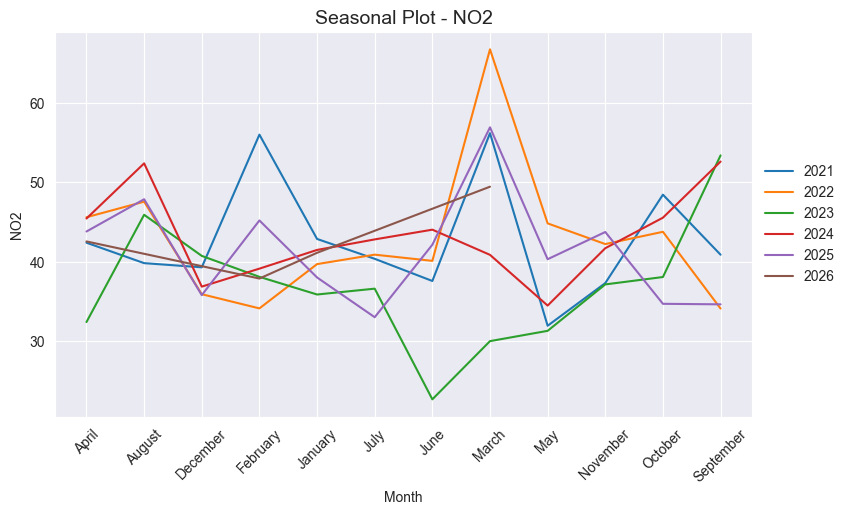

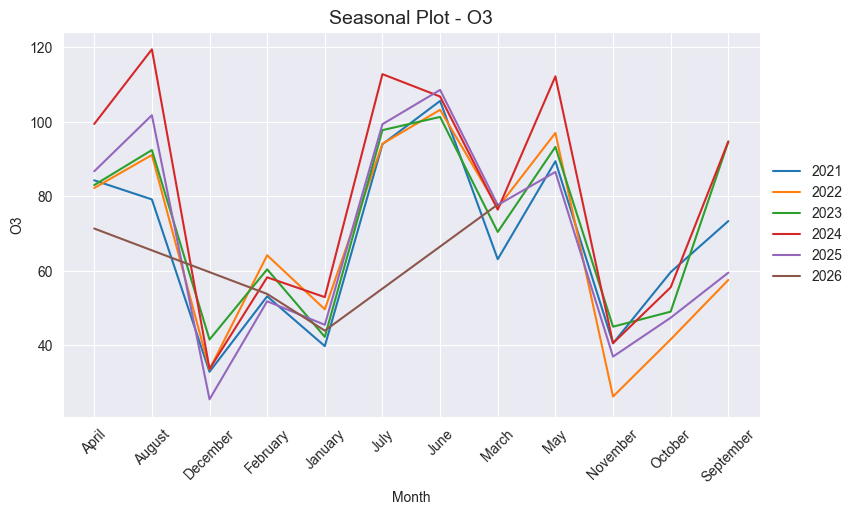

In [993]:
for col in POLLUTANTS:
    df_plot = df[['Month', 'Year', col]].groupby(['Month', 'Year']).mean()[[col]].reset_index()
    years = df_plot['Year'].unique()

    plt.figure(figsize=(9, 5))
    for i, y in enumerate(years):
        if i > 0:
            plt.plot('Month', col, data=df_plot[df_plot['Year'] == y], label=y)

    plt.gca().set(ylabel=col, xlabel='Month')
    plt.xticks(fontsize=10, rotation=45)
    plt.title(f"Seasonal Plot - {col}", fontsize=14)
    plt.ylabel(col)
    plt.xlabel('Month')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig(f'./plots/eda_gios/monthly_plots_{col}.pdf', bbox_inches='tight')
    plt.show()

C:\Users\aleks\AppData\Local\Temp\ipykernel_23064\3560890790.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



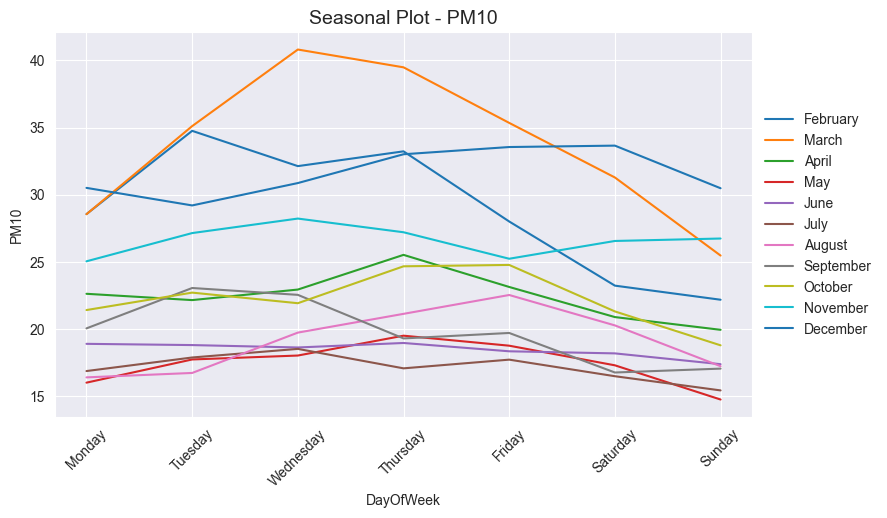

C:\Users\aleks\AppData\Local\Temp\ipykernel_23064\3560890790.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



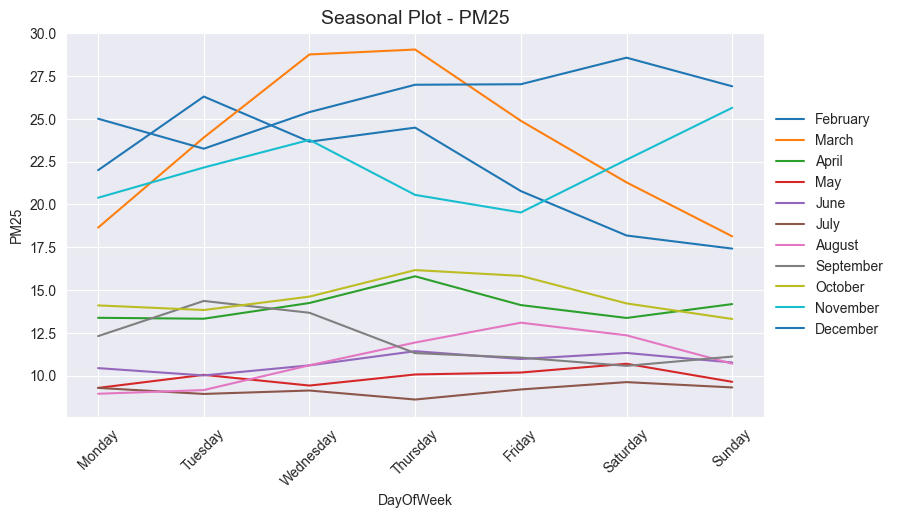

C:\Users\aleks\AppData\Local\Temp\ipykernel_23064\3560890790.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



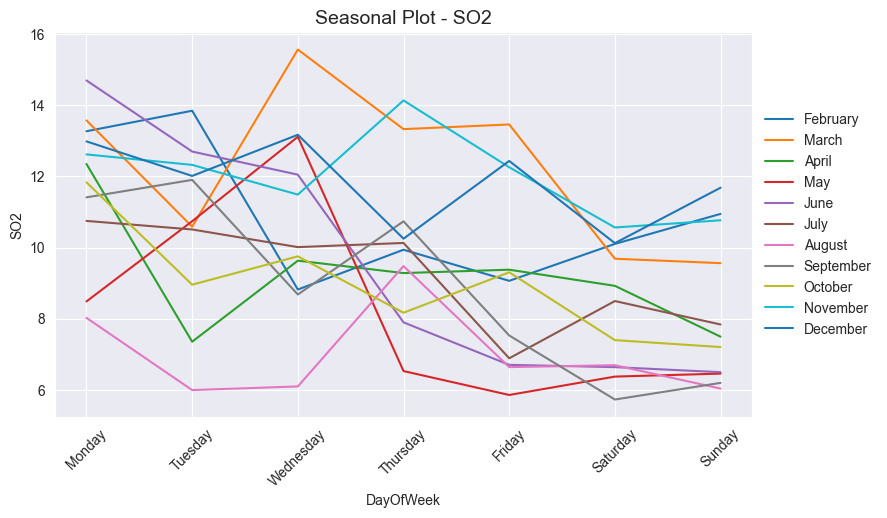

C:\Users\aleks\AppData\Local\Temp\ipykernel_23064\3560890790.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



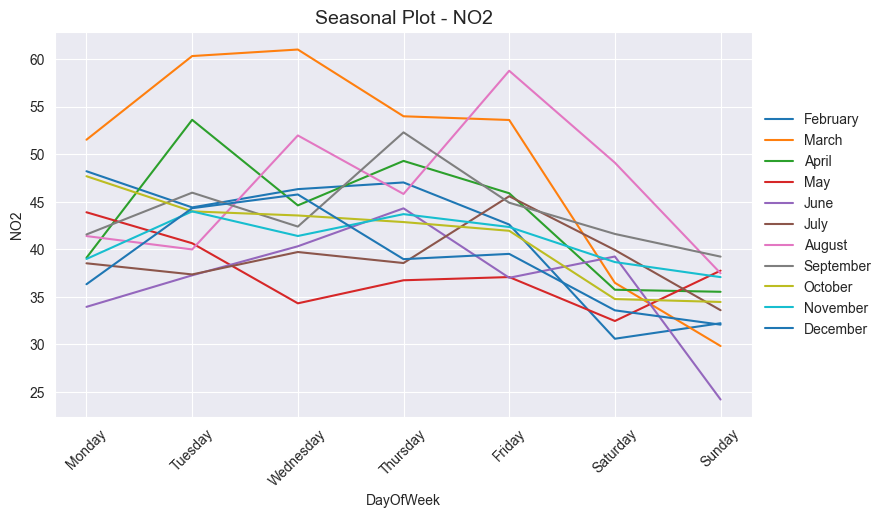

C:\Users\aleks\AppData\Local\Temp\ipykernel_23064\3560890790.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



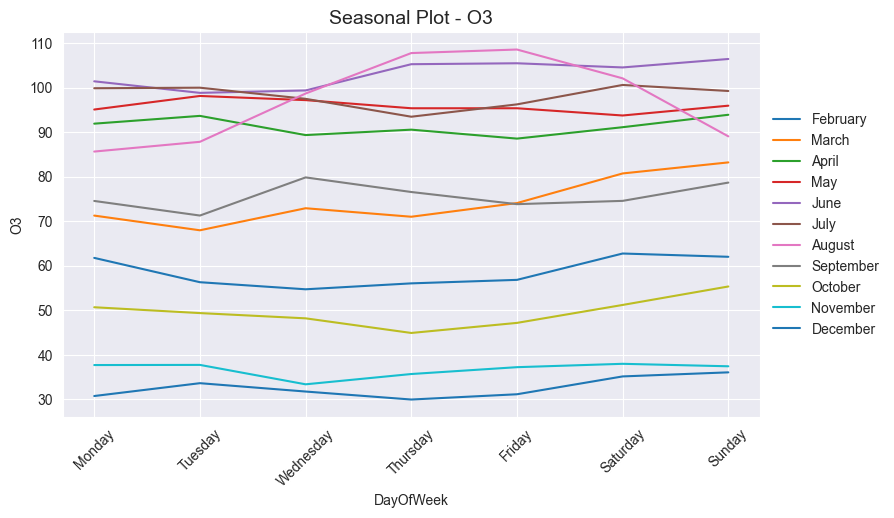

In [994]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['Month']     = pd.Categorical(df['Month'],     categories=month_order, ordered=True)
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order,   ordered=True)

for col in POLLUTANTS:
    df_plot = df[['Month', 'DayOfWeek', col]].groupby(['Month', 'DayOfWeek']).mean()[[col]].reset_index()
    df_plot = df_plot.sort_values(by='DayOfWeek', ascending=True)  

    months = df_plot['Month'].cat.categories  

    plt.figure(figsize=(9, 5))
    for i, m in enumerate(months):
        if i > 0:
            plt.plot('DayOfWeek', col, data=df_plot[df_plot['Month'] == m], label=m)

    plt.gca().set(ylabel=col, xlabel='DayOfWeek')
    plt.xticks(fontsize=10, rotation=45)
    plt.title(f'Seasonal Plot - {col}', fontsize=14)
    plt.xlabel('DayOfWeek')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.savefig(f'./plots/eda_gios/daily_plots_{col}.pdf', bbox_inches='tight')
    plt.show()

In [995]:
df_to_save = df.drop(['Year', 'Month', 'DayOfWeek', 'Season', 'Working_day', 'CO', 	'season_2'], axis=1)

In [996]:
df_to_save.to_csv("./data/cleaned_gios_daily.csv")